# \Lab 01 Cheatsheet
**Introduction to Computer Vision & Computer Vision Applications** · FAST-NUCES Karachi

### Contents
| # | Section | # | Section |
|---|---|---|---|
| 0 | Setup & helper functions | 11.7 | Adding text & drawing shapes |
| 1 | Theory: terminology, applications, DIP pipeline | 11.8 | Analysing pixels with Pandas |
| 2 | Library comparison | 11.9 | Image thresholding |
| 3 | Digital image anatomy & coordinates | 11.10 | Image rotation (+ flip, translate) |
| 11.1 | Reading & displaying | 11.11 | Image blending |
| 11.2 | Grayscale | 11.12 | Histogram equalization (+ CLAHE) |
| 11.3 | Saving & colour spaces *(missing from manual's numbering)* | 12 | Extras: split/merge, edges |
| 11.4 | Resizing | 13 | **Lab Template** (copy-paste) |
| 11.5 | Filtering / blur | 14 | Master function index |
| 11.6 | Cropping | 15 | Common mistakes checklist |

---
## 0. Setup & helper functions
Run this cell first. It imports everything and defines three helpers used throughout:

| Helper | Purpose |
|---|---|
| `load_image(path)` | `cv2.imread` with a file-not-found error if the file is missing |
| `show(images, titles, cols)` | Display one or many images in a grid. **Expects RGB for colour images**; 2-D arrays are shown as grayscale on a fixed 0-255 scale |
| `describe_image(img)` | Print shape / dtype / min / max / mean in one line |

> **Google Colab?** Uncomment the upload snippet in the cell below to upload `Sukuna.jpeg` / `Gojo.jpeg`.

In [3]:
# ============================================================
# IMPORTS
# ============================================================
import os, math
import cv2                              # OpenCV  -> reading, processing, drawing
import numpy as np                      # images ARE NumPy arrays
import pandas as pd                     # tabular analysis of pixel values
import matplotlib.pyplot as plt         # inline display in Jupyter
from IPython.display import display     # pretty-print DataFrames

def show(images, titles=None, cols=3, figsize=None):
    if not isinstance(images, (list, tuple)):
        images = [images]
    if titles is None:
        titles = [''] * len(images)
    rows = (len(images) + cols - 1) // cols
    plt.figure(figsize=figsize or (4 * cols, 4 * rows))
    for i, (img, title) in enumerate(zip(images, titles), 1):
        ax = plt.subplot(rows, cols, i)
        if img.ndim == 2:
            ax.imshow(img, cmap='gray', vmin=0, vmax=255)
        else:
            ax.imshow(img)
        ax.set_title(title)
        ax.axis('off')
    plt.tight_layout()

plt.rcParams['figure.dpi'] = 70          # keeps inline figures (and the .ipynb file) small
print("OpenCV :", cv2.__version__)
print("NumPy  :", np.__version__)
print("Pandas :", pd.__version__)

# ============================================================
# CONFIG  — edit these paths
# ============================================================
IMAGE_PATH  = 'sukuna.jpg'      # main image used in the manual
IMAGE2_PATH = 'gojo.png'         # second real image (used for blending)
OUTPUT_DIR  = 'cheatsheet_outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Load the two real workspace images once.
img_bgr = cv2.imread(IMAGE_PATH)
image2 = cv2.imread(IMAGE2_PATH)
if img_bgr is None: raise FileNotFoundError(IMAGE_PATH)
if image2 is None: raise FileNotFoundError(IMAGE2_PATH)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
image2_rgb = cv2.cvtColor(image2, cv2.COLOR_BGR2RGB)
img2_rgb = image2_rgb
gray_image = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
image1 = img_rgb
image1_resized = cv2.resize(image1, (image2_rgb.shape[1], image2_rgb.shape[0]))

# --- Google Colab only: uncomment to upload your images -------
# from google.colab import files
# files.upload()

OpenCV : 5.0.0
NumPy  : 2.3.5
Pandas : 2.3.3


---
# 11. Basic Image Operations
## 11.1 Reading and displaying an image

| Function | What it does | Parameters |
|---|---|---|
| `cv2.imread(filename, flags)` | Loads an image from disk into a NumPy array. **Returns `None` (no error) if the path is wrong** → always check. | `filename`: path string.<br>`flags`: `cv2.IMREAD_COLOR` (=1, default; 3-ch BGR, drops alpha) · `cv2.IMREAD_GRAYSCALE` (=0; 1-ch) · `cv2.IMREAD_UNCHANGED` (=-1; keeps alpha channel) |
| `cv2.cvtColor(src, code)` | Converts colour space. Used here for **BGR → RGB** so Matplotlib shows true colours. | `src`: input image.<br>`code`: conversion flag e.g. `cv2.COLOR_BGR2RGB` |
| `plt.figure(figsize=(w, h))` | Creates a figure canvas. | `figsize`: size in **inches** `(width, height)` |
| `plt.imshow(X, cmap=None)` | Draws the image on the axes. | `X`: RGB (H,W,3) or 2-D array.<br>`cmap`: colormap — **must be `'gray'` for 2-D arrays**, otherwise Matplotlib paints with *viridis* (false colours). |
| `plt.title(label, fontsize, color, pad)` | Title above the image. | `fontsize`: text size · `color`: any Matplotlib colour · `pad`: gap (points) between title and image |
| `plt.axis('off')` | Hides x/y axes & ticks for a clean look. | `'off'` / `'on'` |
| `plt.show()` | Renders the figure. | — |
| `cv2.imshow(winname, mat)` | Opens a **separate desktop window** (not for Jupyter/Colab — it hangs/crashes the kernel). | `winname`: window title · `mat`: image (**BGR**, no conversion needed) |
| `cv2.waitKey(delay)` | Waits for a key press. Required after `imshow` for the window to render. | `delay` ms; `0` = wait forever. Returns key code |
| `cv2.destroyAllWindows()` | Closes all OpenCV windows. | — |


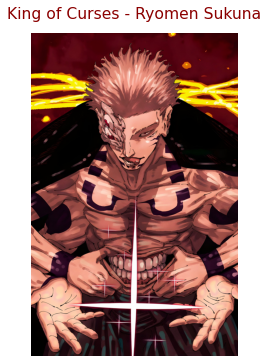

In [4]:
# ---------- Template: read → validate → convert → display ----------
image_path = IMAGE_PATH
image = cv2.imread(image_path)                       # BGR uint8 array (or None)

if image is None:                                    # ALWAYS validate
    print("Error: Image not found.")
else:# (cheatsheet only) keep the notebook runnable
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)   # BGR -> RGB

    plt.figure(figsize=(8, 6))
    plt.axis('off')
    plt.title('King of Curses - Ryomen Sukuna', fontsize=16, color='darkred', pad=15)
    plt.imshow(image_rgb)
    plt.show()

---
## 11.2 Grayscale image

| Function | What it does | Parameters |
|---|---|---|
| `cv2.cvtColor(src, cv2.COLOR_BGR2GRAY)` | Converts 3-channel BGR → single-channel intensity image (shape `(H,W)`). Uses the luminosity formula **Y = 0.299·R + 0.587·G + 0.114·B** | `src`: BGR image · `code`: `COLOR_BGR2GRAY` (use `COLOR_RGB2GRAY` if the image is RGB) |
| `cv2.imread(path, cv2.IMREAD_GRAYSCALE)` | Loads directly as grayscale — skips the conversion step | see 11.1 |
| `plt.imshow(gray, cmap='gray')` | **`cmap='gray'` is required**, else Matplotlib applies a false-colour map | `cmap`: colormap name; `vmin/vmax` fix the display range |

**Why grayscale?** 1 channel instead of 3 → 3× less data, faster, and many algorithms (thresholding, edges, histogram equalization, feature detectors) only need intensity.

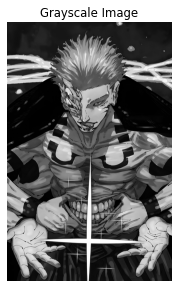

In [5]:
# ---------- Template ----------
image = cv2.imread(IMAGE_PATH)
if image is None: raise FileNotFoundError(IMAGE_PATH)

gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)      # BGR -> GRAY

plt.imshow(gray_image, cmap='gray')    # cmap='gray' is REQUIRED for 2-D arrays
plt.title('Grayscale Image')
plt.axis('off')                        # hide axes for a cleaner look
plt.show()

---
## 11.3 Saving images & other colour spaces
*(The manual's numbering jumps from 11.2 to 11.4 — this section fills the gap with two things you'll need constantly.)*

| Function | What it does | Parameters |
|---|---|---|
| `cv2.imwrite(filename, img, params)` | Saves an image. **Expects BGR** — don't save an RGB array or the colours swap. Returns `True/False`. | `filename`: extension decides format (`.jpg/.png`) · `params`: e.g. `[cv2.IMWRITE_JPEG_QUALITY, 90]` (0-100) or `[cv2.IMWRITE_PNG_COMPRESSION, 3]` (0-9) |
| `cv2.cvtColor(img, code)` | Other useful codes | `COLOR_BGR2RGB` · `COLOR_RGB2BGR` · `COLOR_BGR2GRAY` · `COLOR_GRAY2BGR` (1→3 ch) · `COLOR_BGR2HSV` (H 0-179, S/V 0-255) · `COLOR_BGR2LAB` · `COLOR_BGR2YCrCb` |

JPG saved: True | PNG saved: True | folder: ['saved_jpg.jpg', 'saved_png.png']
HSV shape: (4077, 2598, 3) | H range: 0 - 179 (OpenCV hue is 0-179)
gray3 shape: (4077, 2598, 3)


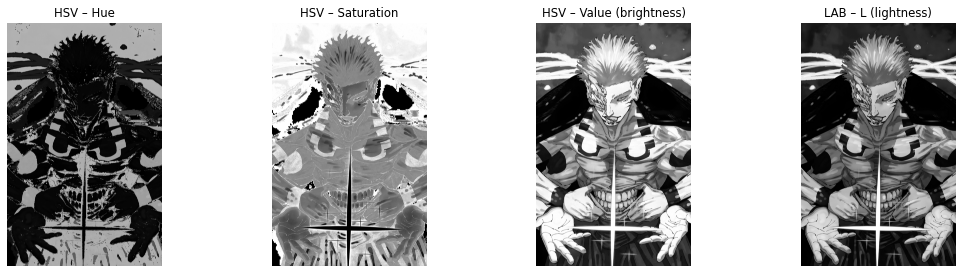

In [6]:
# ---------- Save ----------
ok = cv2.imwrite(os.path.join(OUTPUT_DIR, 'saved_jpg.jpg'), img_bgr, [cv2.IMWRITE_JPEG_QUALITY, 90])
ok2 = cv2.imwrite(os.path.join(OUTPUT_DIR, 'saved_png.png'), img_bgr)
print("JPG saved:", ok, "| PNG saved:", ok2, "| folder:", os.listdir(OUTPUT_DIR))

# ---------- Colour-space conversions ----------
hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
gray3 = cv2.cvtColor(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY), cv2.COLOR_GRAY2BGR)   # gray stored as 3 channels
print("HSV shape:", hsv.shape, "| H range:", hsv[..., 0].min(), "-", hsv[..., 0].max(), "(OpenCV hue is 0-179)")
print("gray3 shape:", gray3.shape)

# HSV / LAB are NOT displayable as-is; show a single channel each
show([hsv[..., 0], hsv[..., 1], hsv[..., 2], lab[..., 0]],
     ['HSV – Hue', 'HSV – Saturation', 'HSV – Value (brightness)', 'LAB – L (lightness)'], cols=4)

---
## 11.4 Resize image

| Function | What it does | Parameters |
|---|---|---|
| `cv2.resize(src, dsize, fx, fy, interpolation)` | Changes image size. Give **either** an absolute size `dsize` **or** scale factors `fx, fy`. | `src`: image.<br>`dsize`: `(width, height)` in pixels — **note: width first**; pass `None` to use `fx/fy`.<br>`fx, fy`: horizontal / vertical scale factors (0.5 = half). Using the *same* value keeps aspect ratio.<br>`interpolation`: resampling method (table below) |
| `img.shape[:2]` | Returns `(height, width)` — used to read the new resolution. | slice `[:2]` drops the channel count |

**Interpolation flags**
| Flag | Best for | Notes |
|---|---|---|
| `cv2.INTER_NEAREST` | speed, label masks | blocky; no new values created |
| `cv2.INTER_LINEAR` | **default**, general / zoom-in | bilinear |
| `cv2.INTER_CUBIC` | better quality **enlarging** | slower (bicubic) |
| `cv2.INTER_AREA` | **shrinking** | best anti-aliased result when downsizing |
| `cv2.INTER_LANCZOS4` | highest-quality enlarging | slowest |

> **Careful:** `shape` is `(height, width)` but `dsize` is `(width, height)`. The manual prints `"{width} x {height}"` after unpacking `shape[:2]` into `height, width` — that is the correct order for *resolution*.

Original Resolution: 2598 x 4077
New Resolution:      1299 x 2038


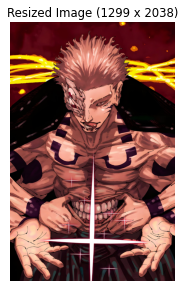

In [7]:
# ---------- Template: resize by SCALE FACTOR (keeps aspect ratio) ----------
scale_factor = 0.5
resized_image = cv2.resize(img_rgb, None, fx=scale_factor, fy=scale_factor)   # dsize=None → use fx, fy

new_height, new_width           = resized_image.shape[:2]
original_height, original_width = img_rgb.shape[:2]

print(f"Original Resolution: {original_width} x {original_height}")
print(f"New Resolution:      {new_width} x {new_height}")

plt.imshow(resized_image)
plt.title(f'Resized Image ({new_width} x {new_height})')
plt.axis('off')
plt.show()

Fixed size -> (224, 224, 3)
Keep aspect -> (470, 300, 3)


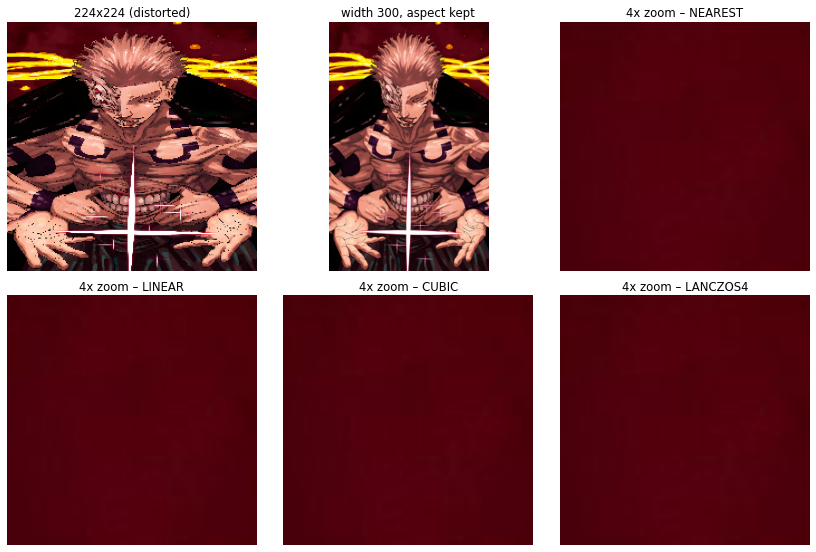

In [8]:
# ---------- Resize to an EXACT size  (dsize = (width, height)) ----------
fixed = cv2.resize(img_rgb, (224, 224))                      # e.g. CNN input — aspect ratio is NOT kept
print("Fixed size ->", fixed.shape)

# ---------- Resize to a target width while keeping aspect ratio ----------
target_w = 300
ratio    = target_w / img_rgb.shape[1]
keep_ar  = cv2.resize(img_rgb, (target_w, int(img_rgb.shape[0] * ratio)), interpolation=cv2.INTER_AREA)
print("Keep aspect ->", keep_ar.shape)

# ---------- Interpolation comparison (shrink then enlarge a patch) ----------
patch = img_rgb[:100, :100]
big = {name: cv2.resize(patch, None, fx=4, fy=4, interpolation=flag)
       for name, flag in [('NEAREST', cv2.INTER_NEAREST), ('LINEAR', cv2.INTER_LINEAR),
                          ('CUBIC', cv2.INTER_CUBIC),     ('LANCZOS4', cv2.INTER_LANCZOS4)]}
show([fixed, keep_ar] + list(big.values()),
     ['224x224 (distorted)', f'width {target_w}, aspect kept'] + [f'4x zoom – {k}' for k in big], cols=3)

---
## 11.5 Image filtering (blur)

Filtering = sliding a small **kernel** (matrix) over the image and replacing each pixel by a weighted combination of its neighbours. Blurring **smooths noise** but also softens edges.

| Function | What it does | Parameters |
|---|---|---|
| `cv2.GaussianBlur(src, ksize, sigmaX, sigmaY, borderType)` | Weighted-average blur — closer pixels weigh more (bell curve). Most common smoothing before edge detection / thresholding. | `ksize`: `(w, h)` kernel size, **must be positive & ODD** (3,5,…,31) — bigger = more blur.<br>`sigmaX`: std-dev in X; **`0` ⇒ computed from ksize**: σ = 0.3·((k−1)·0.5 − 1) + 0.8.<br>`sigmaY`: defaults to sigmaX |
| `cv2.blur(src, ksize)` | Plain **box/mean** filter (all neighbours equal weight). | `ksize`: `(w, h)` |
| `cv2.medianBlur(src, ksize)` | Replaces pixel by the **median** of neighbours — best for **salt-and-pepper noise**, keeps edges sharper. | `ksize`: single **odd int** (e.g. 5) |
| `cv2.bilateralFilter(src, d, sigmaColor, sigmaSpace)` | **Edge-preserving** smoothing. | `d`: neighbourhood diameter · `sigmaColor`: how different colours may be and still mix · `sigmaSpace`: spatial reach |
| `cv2.filter2D(src, ddepth, kernel)` | Apply **any custom kernel** (sharpen, emboss, edge…). | `ddepth`: output depth (`-1` = same as input) · `kernel`: your float matrix |

> **Manual mismatch to note:** the code comment says "(5, 5) is the kernel size" but the code actually uses `(31, 31)` — a *very* strong blur. Larger kernel ⇒ more blur and slower.

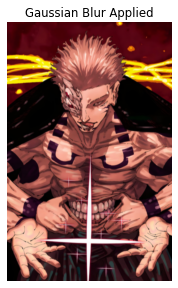

Sigma OpenCV derives when sigma=0 and ksize=31: 5.0


In [9]:
# ---------- Template (manual): Gaussian blur on an RGB image ----------
# (5, 5) = kernel size (must be odd) ; 0 = let OpenCV compute sigma from the kernel size
blurred_image = cv2.GaussianBlur(img_rgb, (31, 31), 0)

plt.imshow(blurred_image)
plt.title('Gaussian Blur Applied')
plt.axis('off')
plt.show()

k = 31
print("Sigma OpenCV derives when sigma=0 and ksize=31:", round(0.3 * ((k - 1) * 0.5 - 1) + 0.8, 2))

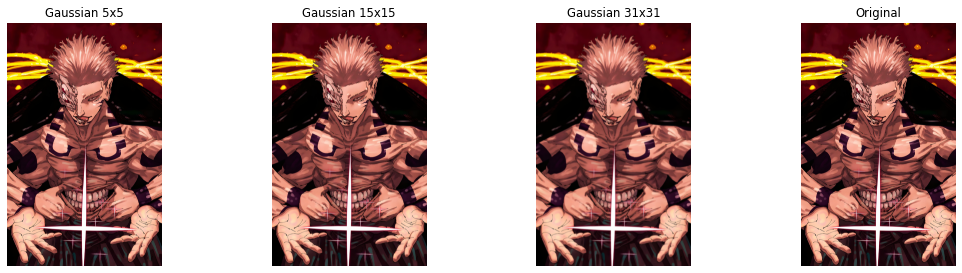

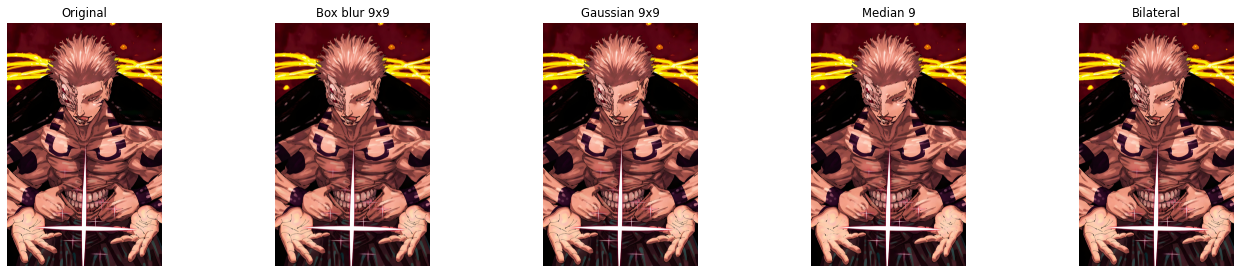

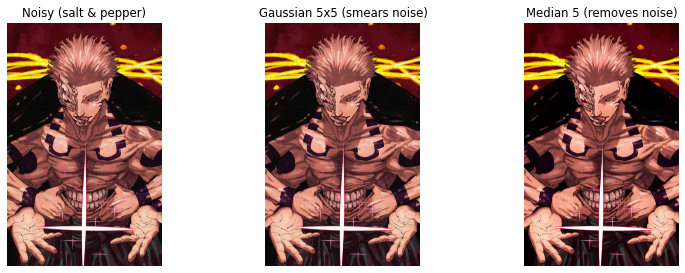

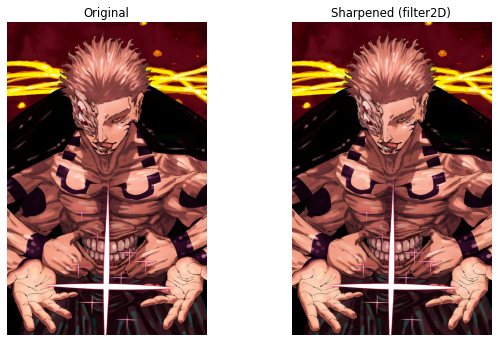

In [10]:
# ---------- Effect of kernel size ----------
show([cv2.GaussianBlur(img_rgb, (k, k), 0) for k in (5, 15, 31)] + [img_rgb],
     ['Gaussian 5x5', 'Gaussian 15x15', 'Gaussian 31x31', 'Original'], cols=4)

# ---------- Compare blur types ----------
show([img_rgb,
      cv2.blur(img_rgb, (9, 9)),
      cv2.GaussianBlur(img_rgb, (9, 9), 0),
      cv2.medianBlur(img_rgb, 9),
      cv2.bilateralFilter(img_rgb, d=9, sigmaColor=75, sigmaSpace=75)],
     ['Original', 'Box blur 9x9', 'Gaussian 9x9', 'Median 9', 'Bilateral'], cols=5)

# ---------- Median vs Gaussian on salt-and-pepper noise ----------
noisy = img_rgb.copy()
rng = np.random.default_rng(1)
mask = rng.random(noisy.shape[:2])
noisy[mask < 0.03] = 0          # pepper
noisy[mask > 0.97] = 255        # salt
show([noisy, cv2.GaussianBlur(noisy, (5, 5), 0), cv2.medianBlur(noisy, 5)],
     ['Noisy (salt & pepper)', 'Gaussian 5x5 (smears noise)', 'Median 5 (removes noise)'], cols=3)

# ---------- Custom kernel with filter2D: sharpen ----------
sharpen_kernel = np.array([[ 0, -1,  0],
                           [-1,  5, -1],
                           [ 0, -1,  0]], dtype=np.float32)
sharpened = cv2.filter2D(img_rgb, -1, sharpen_kernel)
show([img_rgb, sharpened], ['Original', 'Sharpened (filter2D)'], cols=2, figsize=(9, 5))

---
## 11.6 Cropping

OpenCV has **no crop function** — images are NumPy arrays, so you crop with **slicing**:

```python
cropped = image[y_start:y_end, x_start:x_end]      # rows first, then columns
```

| Piece | Meaning |
|---|---|
| `image.shape[:2]` | `(height, width)` |
| `width // 2` | integer (floor) division → exact midpoint column `mid_x` |
| `image[:, :mid_x]` | `:` = all rows (full height), `:mid_x` = columns from 0 up to the midpoint → **LEFT half** |
| `image[:, mid_x:]` | → **RIGHT half** |
| `image[:mid_y, :]` / `image[mid_y:, :]` | → **TOP** / **BOTTOM** half |


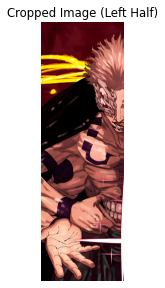

In [11]:
# ---------- Template (manual): crop the left half ----------
height, width = img_rgb.shape[:2]          # (rows, cols)
mid_x = width // 2                         # horizontal midpoint

# Syntax: image[y_start:y_end, x_start:x_end]
cropped_image = img_rgb[:, :mid_x]         # LEFT half  (all rows, columns 0 → mid_x)
# cropped_image = img_rgb[:, mid_x:]       # RIGHT half

plt.imshow(cropped_image)
plt.title('Cropped Image (Left Half)')
plt.axis('off')
plt.show()

Original corner changed by editing the view?  -> True
Original corner changed by editing the copy?  -> False


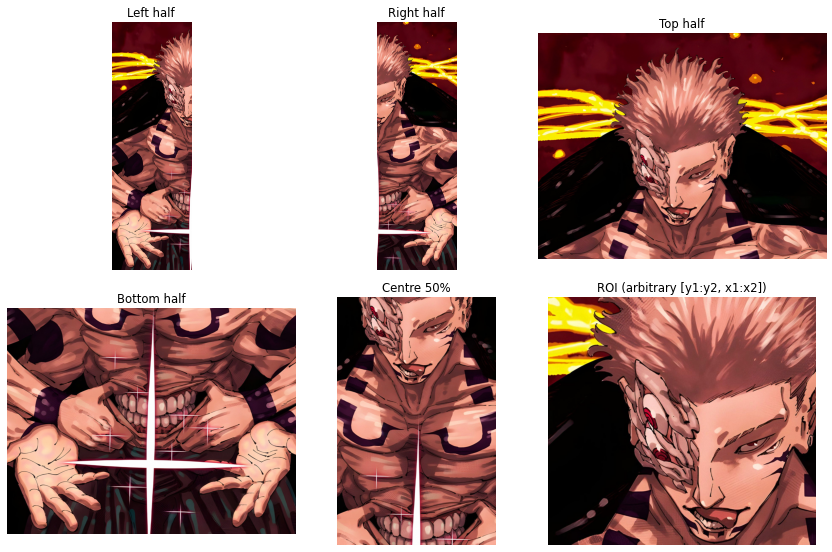

In [12]:
# ---------- More crops ----------
mid_y = height // 2
left   = img_rgb[:, :mid_x]
right  = img_rgb[:, mid_x:]
top    = img_rgb[:mid_y, :]
bottom = img_rgb[mid_y:, :]

# Centre crop of 50% width/height
y1, y2 = height // 4, 3 * height // 4
x1, x2 = width  // 4, 3 * width  // 4
center = img_rgb[y1:y2, x1:x2]

# Arbitrary region of interest (ROI):  img[y1:y2, x1:x2]  (here as fractions of height / width)
roi = img_rgb[int(height*.14):int(height*.43), int(width*.18):int(width*.67)]

show([left, right, top, bottom, center, roi],
     ['Left half', 'Right half', 'Top half', 'Bottom half', 'Centre 50%', 'ROI (arbitrary [y1:y2, x1:x2])'], cols=3)

# ---------- VIEW vs COPY pitfall ----------
original = img_rgb.copy()
view = original[0:50, 0:50]               # a VIEW
view[:] = 255                             # paints the ORIGINAL white in that corner
print("Original corner changed by editing the view?  ->", bool((original[0:50, 0:50] == 255).all()))

safe = img_rgb[0:50, 0:50].copy()         # independent copy
safe[:] = 0
print("Original corner changed by editing the copy?  ->", bool((img_rgb[0:50, 0:50] == 0).all()))

---
## 11.7 Adding text on an image (+ drawing shapes)

| Function | What it does | Parameters |
|---|---|---|
| `cv2.putText(img, text, org, fontFace, fontScale, color, thickness, lineType, bottomLeftOrigin)` | Draws text **in place** (modifies `img`; also returns it). | `img`: image to draw on.<br>`text`: string (**ASCII only** with Hershey fonts).<br>`org`: **(x, y) of the BOTTOM-LEFT corner of the text**.<br>`fontFace`: e.g. `cv2.FONT_HERSHEY_SIMPLEX`, `_PLAIN`, `_DUPLEX`, `_COMPLEX`, `_TRIPLEX`, `_SCRIPT_SIMPLEX`, `+cv2.FONT_ITALIC`.<br>`fontScale`: size multiplier.<br>`color`: tuple **in the same channel order as the image** — RGB image: `(255,0,0)` = red; BGR image: `(0,0,255)` = red.<br>`thickness`: stroke px.<br>`lineType`: `cv2.LINE_AA` = smooth anti-aliased edges |
| `cv2.getTextSize(text, fontFace, fontScale, thickness)` | Returns `((text_w, text_h), baseline)` — use it to centre text or draw a background box. | same as putText |
| `cv2.rectangle(img, pt1, pt2, color, thickness)` | Rectangle from top-left `pt1` to bottom-right `pt2`. | `thickness=-1` ⇒ **filled** |
| `cv2.circle(img, center, radius, color, thickness)` | Circle. | `center=(x,y)` |
| `cv2.line(img, pt1, pt2, color, thickness)` | Straight line. | |
| `cv2.arrowedLine(img, pt1, pt2, color, thickness, tipLength=0.1)` | Line with arrow head at `pt2`. | `tipLength` fraction of line length |
| `cv2.ellipse(img, center, axes, angle, startAngle, endAngle, color, thickness)` | Ellipse / arc. | `axes=(half_w, half_h)` |
| `cv2.polylines(img, [pts], isClosed, color, thickness)` | Polygon outline. | `pts`: int32 array of points |

> The manual draws at a hard-coded `(150, 150)` with `fontScale=1.5`; on a different-size image that may land off-target. Scaling position/size from `w, h` (below) is more robust.

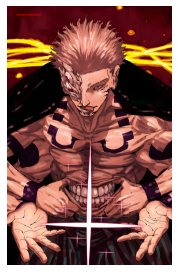

In [13]:
# ---------- Template (manual): red text on an RGB image ----------
text = "Domain Expansion"
font = cv2.FONT_HERSHEY_SIMPLEX

canvas = img_rgb.copy()                    # putText modifies in place → draw on a COPY
# Parameters: image, text, bottom-left corner (x, y), font, fontScale, color, thickness
cv2.putText(canvas, text, (150, 150), font, 1.5, (255, 0, 0), 2)    # (255,0,0) in RGB = RED

plt.imshow(canvas)
plt.axis('off')
plt.show()

BGR image? red is (0,0,255).  RGB image? red is (255,0,0).  Colour order must match the array!


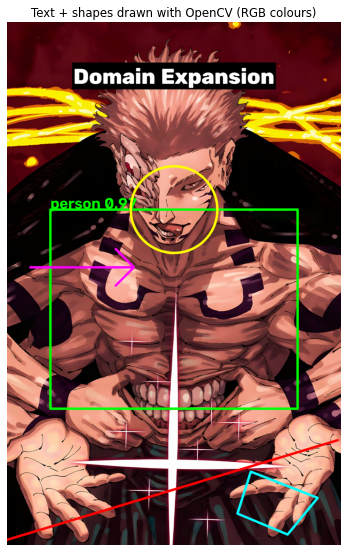

In [14]:
# ---------- Robust version: scale to image size, add a background box, anti-aliased ----------
h, w = img_rgb.shape[:2]
canvas = img_rgb.copy()

text       = "Domain Expansion"
font       = cv2.FONT_HERSHEY_DUPLEX
font_scale = w / 450                       # scales with image width
thickness  = max(1, int(font_scale * 2))

(tw, th), baseline = cv2.getTextSize(text, font, font_scale, thickness)
x = (w - tw) // 2                           # horizontally centred
y = int(h * 0.12)                           # bottom-left corner of the text

cv2.rectangle(canvas, (x - 10, y - th - 10), (x + tw + 10, y + baseline + 10), (0, 0, 0), -1)   # filled black box
cv2.putText(canvas, text, (x, y), font, font_scale, (255, 255, 255), thickness, cv2.LINE_AA)       # white text

# ---------- Other drawing primitives (all positions scale with image size) ----------
P = lambda fx, fy: (int(w * fx), int(h * fy))                       # fraction -> (x, y) pixel point
lw = max(2, w // 150)                                                # line width scales too
cv2.rectangle(canvas, P(.13, .36), P(.87, .74), (0, 255, 0), lw)    # outline box (e.g. a detection box)
cv2.putText(canvas, "person 0.97", (P(.13, .36)[0], P(.13, .36)[1] - 8), cv2.FONT_HERSHEY_SIMPLEX, w / 650, (0, 255, 0), lw, cv2.LINE_AA)
cv2.circle(canvas, P(.5, .36), int(w * .13), (255, 255, 0), lw)     # circle
cv2.line(canvas, P(0, .99), P(.99, .8), (255, 0, 0), lw)            # line
cv2.arrowedLine(canvas, P(.07, .47), P(.38, .47), (255, 0, 255), lw, tipLength=0.25)   # arrow
pts = np.array([P(.73, .86), P(.93, .91), P(.84, .98), P(.69, .94)], np.int32).reshape(-1, 1, 2)
cv2.polylines(canvas, [pts], True, (0, 255, 255), lw)               # polygon

show([canvas], ['Text + shapes drawn with OpenCV (RGB colours)'], cols=1, figsize=(6, 8))

print("BGR image? red is (0,0,255).  RGB image? red is (255,0,0).  Colour order must match the array!")

---
## 11.8 Analyse the image using Pandas

Turn pixels into a table so you can use `describe()`, `mean()`, `corr()` etc.

| Function | What it does | Parameters |
|---|---|---|
| `image.reshape(-1, 3)` | Flattens `(H, W, 3)` → `(H·W, 3)`: **one row per pixel, one column per channel**. | `-1` = "infer this dimension"; `3` = channels |
| `pd.DataFrame(data, columns=[...])` | Builds a table from the 2-D array. | `columns`: names — **`['B','G','R']` because OpenCV is BGR** |
| `df.describe()` | count, mean, std, min, 25 %, 50 %, 75 %, max per column. | `percentiles=[...]` to customise |
| `display(df)` | Pretty-prints a DataFrame in Jupyter. | |
| `pd.options.display.float_format` | Avoid ugly scientific notation like `4.227072e+06` (as in the manual's output). | e.g. `'{:,.2f}'.format` |

In [15]:
# ---------- Template (manual) ----------
image = img_bgr                                          # BGR image (as read by OpenCV)

# Reshape the 3-D array (Height, Width, Channels) into a 2-D array (Total Pixels, Channels)
flattened_image = image.reshape(-1, 3)

# Convert to a DataFrame — column order matches OpenCV's BGR!
image_df = pd.DataFrame(flattened_image, columns=['B', 'G', 'R'])

print("Basic Statistics of Image Pixel Values:")
pd.options.display.float_format = '{:,.2f}'.format       # nicer than 4.227072e+06
display(image_df.describe())

Basic Statistics of Image Pixel Values:


,B,G,R
count,"10,592,046.00","10,592,046.00","10,592,046.00"
mean,58.52,68.33,119.96
std,59.50,73.74,87.99
min,0.00,0.00,0.00
25%,10.00,3.00,43.00
50%,40.00,46.00,97.00
75%,91.00,119.00,209.00
max,255.00,255.00,255.00


Rows (= pixels): 10592046 = H x W = 4077 x 2598

Mean per channel:
 B    58.52
G    68.33
R   119.96
dtype: float64

Dominant channel per pixel (counts):
 R    9641128
B     748439
G     202479
Name: count, dtype: int64

Channel correlation:


,B,G,R
B,1.00,0.85,0.83
G,0.85,1.00,0.93
R,0.83,0.93,1.00


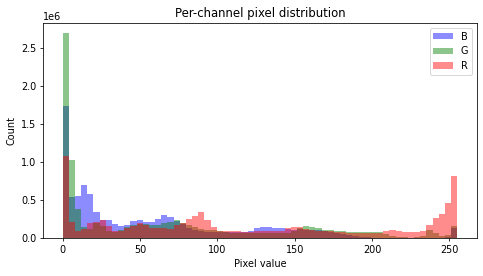

In [16]:
# ---------- Deeper analysis ----------
print("Rows (= pixels):", len(image_df), "= H x W =", image.shape[0], "x", image.shape[1])

print("\nMean per channel:\n", image_df.mean().round(2))
print("\nDominant channel per pixel (counts):\n", image_df.idxmax(axis=1).value_counts())
print("\nChannel correlation:")
display(image_df.corr().round(3))

# Histogram of each channel from the DataFrame
plt.figure(figsize=(8, 4))
for col, colour in zip(['B', 'G', 'R'], ['blue', 'green', 'red']):
    plt.hist(image_df[col], bins=64, range=(0, 255), alpha=0.45, color=colour, label=col)
plt.legend(); plt.xlabel('Pixel value'); plt.ylabel('Count'); plt.title('Per-channel pixel distribution')
plt.show()

---
## 11.9 Image thresholding

Thresholding converts a grayscale image into a binary (or clipped) image by comparing each pixel against a threshold — the simplest **segmentation** method.

| Function | What it does | Parameters |
|---|---|---|
| `ret, dst = cv2.threshold(src, thresh, maxval, type)` | Applies a **global** threshold. Returns **two values**. | `src`: **single-channel** (gray) image.<br>`thresh`: threshold limit.<br>`maxval`: value assigned to "passing" pixels (used by BINARY types; **255 = pure white**).<br>`type`: mode (table below).<br>**returns** `ret` = the threshold actually used (matters with OTSU/TRIANGLE), `dst` = result |
| `cv2.adaptiveThreshold(src, maxValue, adaptiveMethod, thresholdType, blockSize, C)` | Threshold is computed **per local neighbourhood** — great for uneven lighting. | `adaptiveMethod`: `ADAPTIVE_THRESH_MEAN_C` or `ADAPTIVE_THRESH_GAUSSIAN_C`.<br>`thresholdType`: `THRESH_BINARY` / `THRESH_BINARY_INV`.<br>`blockSize`: odd neighbourhood size.<br>`C`: constant subtracted from the local mean |

**Threshold types** (for pixel value `v`, threshold `T`, max value `M`)
| Type | Result |
|---|---|
| `cv2.THRESH_BINARY` | `M` if `v > T` else `0` |
| `cv2.THRESH_BINARY_INV` | `0` if `v > T` else `M` |
| `cv2.THRESH_TRUNC` | `T` if `v > T` else `v` (clip; `maxval` ignored) |
| `cv2.THRESH_TOZERO` | `v` if `v > T` else `0` |
| `cv2.THRESH_TOZERO_INV` | `0` if `v > T` else `v` |
| `+ cv2.THRESH_OTSU` | **auto-computes best T** from the histogram (set `thresh=0`; image must be 8-bit) — combine with `+` |
| `+ cv2.THRESH_TRIANGLE` | alternative automatic threshold |

> **Manual detail:** the manual uses `cv2.threshold(gray, 100, 200, THRESH_BINARY)` → pixels `> 100` become **200**, the rest **0**. It *looks* pure white in Matplotlib only because `imshow` auto-stretches the display range to the data's min/max. Real pure white is `255`; with `cv2.imshow` that 200 would appear light-gray.

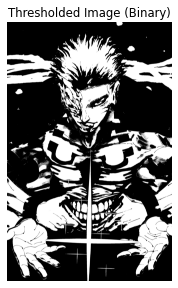

ret (threshold actually used): 100.0
Unique output values: [  0 200]  <- 0 and 200 (not 255!)


In [17]:
# ---------- Template (manual) ----------
gray_image = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)        # thresholding works on single-channel images

# Parameters: source image, threshold value, max value, thresholding technique
ret, thresholded_image = cv2.threshold(gray_image, 100, 200, cv2.THRESH_BINARY)

plt.imshow(thresholded_image, cmap='gray')                     # cmap='gray' required
plt.title('Thresholded Image (Binary)')
plt.axis('off')
plt.show()

print("ret (threshold actually used):", ret)
print("Unique output values:", np.unique(thresholded_image), " <- 0 and 200 (not 255!)")

Otsu chose T = 105 | Triangle chose T = 7


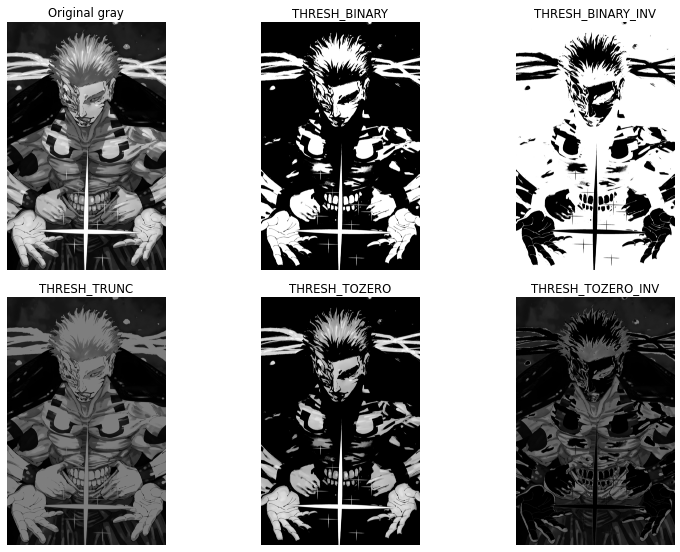

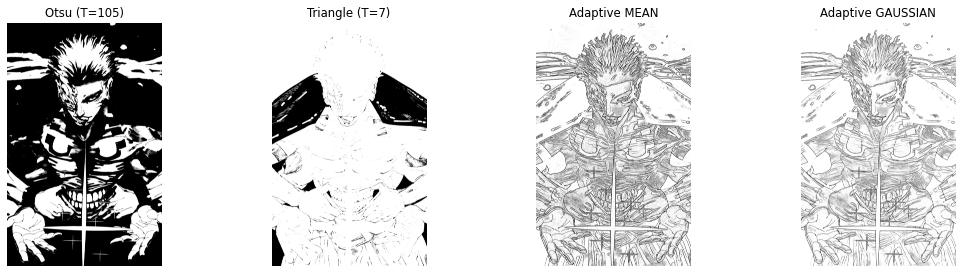

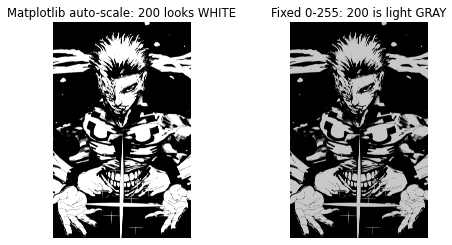

In [18]:
# ---------- All threshold types side by side (T=127, M=255) ----------
T, M = 127, 255
modes = {
    'BINARY':      cv2.THRESH_BINARY,
    'BINARY_INV':  cv2.THRESH_BINARY_INV,
    'TRUNC':       cv2.THRESH_TRUNC,
    'TOZERO':      cv2.THRESH_TOZERO,
    'TOZERO_INV':  cv2.THRESH_TOZERO_INV,
}
outs = [gray_image] + [cv2.threshold(gray_image, T, M, m)[1] for m in modes.values()]
show(outs, ['Original gray'] + [f'THRESH_{k}' for k in modes], cols=3)

# ---------- Automatic thresholds ----------
t_otsu, otsu = cv2.threshold(gray_image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
t_tri,  tri  = cv2.threshold(gray_image, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_TRIANGLE)
print(f"Otsu chose T = {t_otsu:.0f} | Triangle chose T = {t_tri:.0f}")

# ---------- Adaptive thresholding (local) ----------
blur = cv2.GaussianBlur(gray_image, (5, 5), 0)
ad_mean  = cv2.adaptiveThreshold(blur, 255, cv2.ADAPTIVE_THRESH_MEAN_C,     cv2.THRESH_BINARY, 11, 2)
ad_gauss = cv2.adaptiveThreshold(blur, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2)

show([otsu, tri, ad_mean, ad_gauss],
     [f'Otsu (T={t_otsu:.0f})', f'Triangle (T={t_tri:.0f})', 'Adaptive MEAN', 'Adaptive GAUSSIAN'], cols=4)

# ---------- The display gotcha: auto-scaling vs fixed scale ----------
fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow(thresholded_image, cmap='gray');                 ax[0].set_title('Matplotlib auto-scale: 200 looks WHITE')
ax[1].imshow(thresholded_image, cmap='gray', vmin=0, vmax=255); ax[1].set_title('Fixed 0-255: 200 is light GRAY')
for a in ax: a.axis('off')
plt.show()

---
## 11.10 Image rotation

Rotation is an **affine transformation**: `new_pos = M · [x, y, 1]ᵀ` where `M` is a 2×3 matrix. Two steps: **build M**, then **apply it**.

| Function | What it does | Parameters |
|---|---|---|
| `cv2.getRotationMatrix2D(center, angle, scale)` | Returns the 2×3 rotation matrix. | `center`: pivot **(x, y) = (width/2, height/2)**.<br>`angle`: degrees; **positive = counter-clockwise**, negative = clockwise.<br>`scale`: `1` = same size, `0.5` = shrink |
| `cv2.warpAffine(src, M, dsize, flags, borderMode, borderValue)` | Applies the matrix to every pixel. | `M`: 2×3 matrix.<br>`dsize`: output canvas **(width, height)**.<br>`flags`: interpolation (default `INTER_LINEAR`).<br>`borderMode`: `BORDER_CONSTANT` (default) / `BORDER_REPLICATE` / `BORDER_REFLECT`.<br>`borderValue`: fill colour for empty areas (default black) |
| `cv2.rotate(src, rotateCode)` | **Lossless** 90°/180° rotation (no matrix needed). | `cv2.ROTATE_90_CLOCKWISE`, `cv2.ROTATE_180`, `cv2.ROTATE_90_COUNTERCLOCKWISE` |
| `cv2.flip(src, flipCode)` | Mirror image. | `1` horizontal · `0` vertical · `-1` both |

> Because the canvas stays `(width, height)`, **corners get cut off** and empty space is filled with **black**. To keep the whole rotated image, enlarge the canvas (`rotate_bound` below).

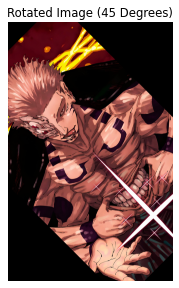

2x3 rotation matrix:
 [[ 7.0710000e-01  7.0710000e-01 -1.0609689e+03]
 [-7.0710000e-01  7.0710000e-01  1.5155945e+03]]


In [19]:
# ---------- Template (manual): rotate 45° about the centre ----------
height, width = img_rgb.shape[:2]
center = (width / 2, height / 2)                              # (x, y) pivot

# Parameters: center of rotation, angle in degrees (positive = counter-clockwise), scale
rotation_matrix = cv2.getRotationMatrix2D(center, 45, 1)

# Parameters: source image, rotation matrix, dimensions of the output image (width, height)
rotated_image = cv2.warpAffine(img_rgb, rotation_matrix, (width, height))

plt.imshow(rotated_image)
plt.title('Rotated Image (45 Degrees)')
plt.axis('off')
plt.show()

print("2x3 rotation matrix:\n", rotation_matrix.round(4))

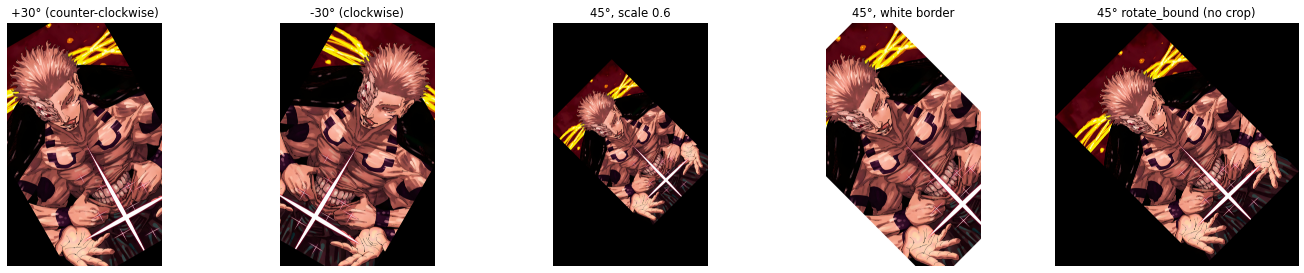

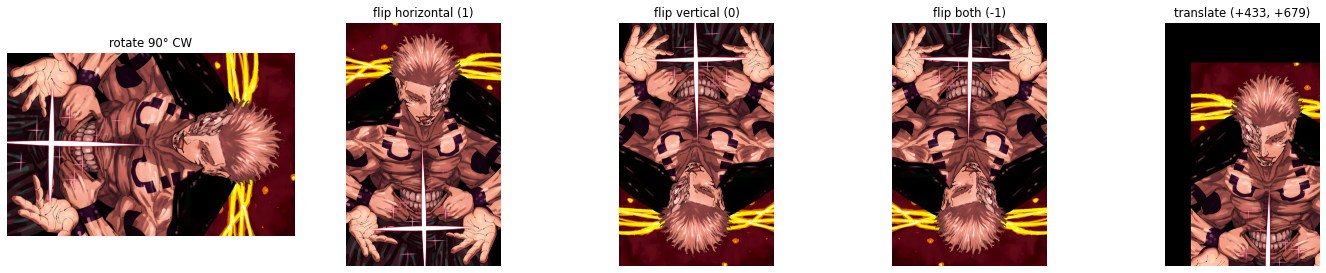

In [20]:
# ---------- Variations ----------
def rotate_bound(img, angle, border=(0, 0, 0)):
    # Rotate WITHOUT cropping: enlarge the canvas to fit the whole rotated image.
    h, w = img.shape[:2]
    cX, cY = w / 2, h / 2
    M = cv2.getRotationMatrix2D((cX, cY), angle, 1.0)
    cos, sin = abs(M[0, 0]), abs(M[0, 1])
    new_w, new_h = int(h * sin + w * cos), int(h * cos + w * sin)
    M[0, 2] += new_w / 2 - cX                      # shift so the centre stays centred
    M[1, 2] += new_h / 2 - cY
    return cv2.warpAffine(img, M, (new_w, new_h), borderValue=border)

ccw   = cv2.warpAffine(img_rgb, cv2.getRotationMatrix2D(center, 30, 1),  (width, height))
cw    = cv2.warpAffine(img_rgb, cv2.getRotationMatrix2D(center, -30, 1), (width, height))
half  = cv2.warpAffine(img_rgb, cv2.getRotationMatrix2D(center, 45, 0.6), (width, height))
white = cv2.warpAffine(img_rgb, cv2.getRotationMatrix2D(center, 45, 1), (width, height), borderValue=(255, 255, 255))
full  = rotate_bound(img_rgb, 45)

show([ccw, cw, half, white, full],
     ['+30° (counter-clockwise)', '-30° (clockwise)', '45°, scale 0.6', '45°, white border', '45° rotate_bound (no crop)'], cols=5)

# ---------- 90° steps, flips & translation ----------
rot90 = cv2.rotate(img_rgb, cv2.ROTATE_90_CLOCKWISE)
flipH = cv2.flip(img_rgb, 1)
flipV = cv2.flip(img_rgb, 0)
flipB = cv2.flip(img_rgb, -1)

# Translation matrix  [[1,0,tx],[0,1,ty]]  → shift right by tx px, down by ty px
tx, ty = width // 6, height // 6
T_mat = np.float32([[1, 0, tx], [0, 1, ty]])
moved = cv2.warpAffine(img_rgb, T_mat, (width, height))

show([rot90, flipH, flipV, flipB, moved],
     ['rotate 90° CW', 'flip horizontal (1)', 'flip vertical (0)', 'flip both (-1)', f'translate (+{tx}, +{ty})'], cols=5)

---
## 11.11 Image blending

| Function | What it does | Parameters |
|---|---|---|
| `cv2.add(src1, src2)` | Pixel-wise **addition with saturation**: result is capped at 255 (never wraps). Blended result is generally **brighter** than either input. | Both images must have **identical size and type** |
| `cv2.addWeighted(src1, alpha, src2, beta, gamma)` | **Weighted blend** (cross-fade): `dst = src1·α + src2·β + γ`. Use `α + β = 1` for a natural mix. | `alpha`, `beta`: weights · `gamma`: brightness offset added to all pixels |
| `cv2.subtract(src1, src2)` | Saturated subtraction (floors at 0). | |
| `cv2.absdiff(src1, src2)` | `|src1 − src2|` — detect **differences** between images. | |
| `cv2.bitwise_and(src1, src2, mask=m)` | Keeps pixels where the mask is white. Used for masking / ROI extraction. | `mask`: 8-bit single-channel |
| `cv2.resize(img1, (w2, h2))` | Force the first image to match the second's size **before** combining. | `(width, height)` of image 2 |

**Saturation vs NumPy wrap-around (uint8):** `200 + 100` → `cv2.add` gives **255**, but plain NumPy `a + b` wraps modulo 256 → **44** (a classic bug!).

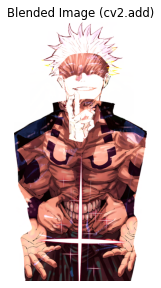

In [21]:
# ---------- Template (manual) ----------
image1_rgb, image2_rgb = img_rgb, img2_rgb                    # (already loaded & converted in Section 0)

# Both images must be the exact same size → resize image1 to match image2
target_height, target_width = image2_rgb.shape[:2]
image1_resized = cv2.resize(image1_rgb, (target_width, target_height))      # dsize = (width, height)

# Matrix addition with saturation arithmetic (caps at 255)
blended_image = cv2.add(image1_resized, image2_rgb)

plt.imshow(blended_image)
plt.title('Blended Image (cv2.add)')
plt.axis('off')
plt.show()

cv2.add      200 + 100 = 300.0   (saturated at 255)
numpy a + b  200 + 100 = 44   (wrapped: 300 mod 256)
cv2.subtract 100 - 200 = -100.0   (floored at 0)


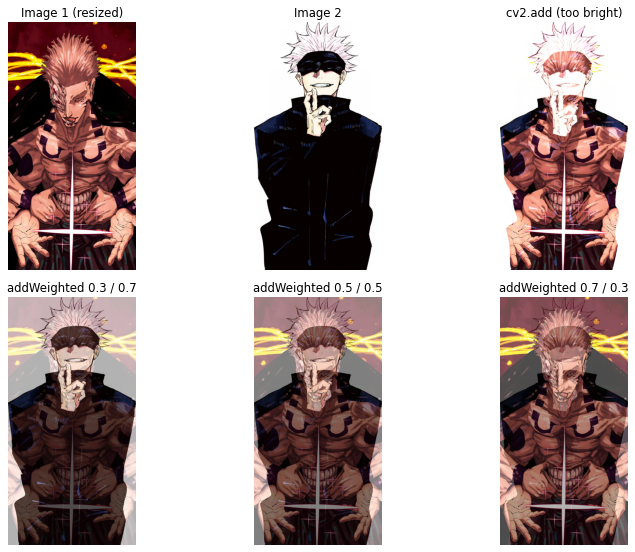

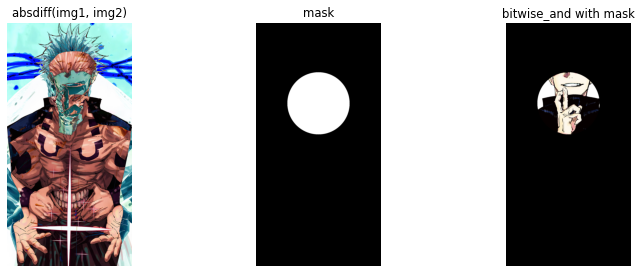

In [22]:
# ---------- Saturation vs wrap-around demo ----------
a = np.array([200], dtype=np.uint8)
b = np.array([100], dtype=np.uint8)
print("cv2.add      200 + 100 =", cv2.add(a, b).ravel()[0], "  (saturated at 255)")
print("numpy a + b  200 + 100 =", (a + b)[0],               "  (wrapped: 300 mod 256)")
print("cv2.subtract 100 - 200 =", cv2.subtract(b, a).ravel()[0], "  (floored at 0)")

# ---------- Weighted blends (alpha + beta = 1 keeps brightness natural) ----------
blend_30_70 = cv2.addWeighted(image1_resized, 0.3, image2_rgb, 0.7, 0)
blend_50_50 = cv2.addWeighted(image1_resized, 0.5, image2_rgb, 0.5, 0)
blend_70_30 = cv2.addWeighted(image1_resized, 0.7, image2_rgb, 0.3, 0)
diff        = cv2.absdiff(image1_resized, image2_rgb)

show([image1_resized, image2_rgb, blended_image, blend_30_70, blend_50_50, blend_70_30],
     ['Image 1 (resized)', 'Image 2', 'cv2.add (too bright)', 'addWeighted 0.3 / 0.7', 'addWeighted 0.5 / 0.5', 'addWeighted 0.7 / 0.3'], cols=3)

# ---------- absdiff + masking ----------
mask = np.zeros(image2_rgb.shape[:2], np.uint8)
cv2.circle(mask, (target_width // 2, target_height // 3), target_width // 4, 255, -1)       # white circle = keep area
masked = cv2.bitwise_and(image2_rgb, image2_rgb, mask=mask)
show([diff, mask, masked], ['absdiff(img1, img2)', 'mask', 'bitwise_and with mask'], cols=3)

---
## 11.12 Histogram equalization

A **histogram** plots how many pixels have each intensity (0-255). A dark / washed-out image has its values **clumped in a narrow range**. *Histogram equalization* spreads them across the full 0-255 range → **higher global contrast** and revealed hidden detail (darkest areas get darker, lightest get lighter).

| Function | What it does | Parameters |
|---|---|---|
| `cv2.imread(path, cv2.IMREAD_GRAYSCALE)` | Loads directly as single-channel (no `cvtColor` needed). | |
| `cv2.equalizeHist(src)` | Global histogram equalization. **8-bit single-channel input only.** | `src`: gray `uint8` image |
| `cv2.createCLAHE(clipLimit, tileGridSize)` → `.apply(img)` | **CLAHE** — *adaptive* equalization on tiles, avoids over-amplifying noise. Usually nicer than global. | `clipLimit`: contrast cap (2-4 typical) · `tileGridSize`: `(8, 8)` tiles |
| `cv2.calcHist(images, channels, mask, histSize, ranges)` | Computes a histogram array of shape `(256, 1)`. | `images`: **list** `[img]` · `channels`: `[0]` · `mask`: `None` for whole image · `histSize`: `[256]` bins · `ranges`: `[0, 256]` |
| `plt.hist(data.ravel(), bins, range)` | Alternative: plot histogram directly from pixel values. | |

**Colour images:** don't equalize R, G, B separately (colours shift). Convert to **YCrCb** (or LAB) and equalize only the brightness channel (`Y` / `L`).

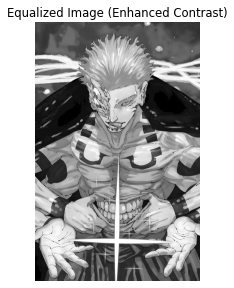

In [23]:
# ---------- Template (manual): read in grayscale → equalize ----------
image = cv2.imread(IMAGE_PATH, cv2.IMREAD_GRAYSCALE)         # single-channel straight from disk
if image is None:
    raise FileNotFoundError(IMAGE_PATH)

equalized_image = cv2.equalizeHist(image)                    # improve contrast

plt.imshow(equalized_image, cmap='gray')
plt.title('Equalized Image (Enhanced Contrast)')
plt.axis('off')
plt.show()

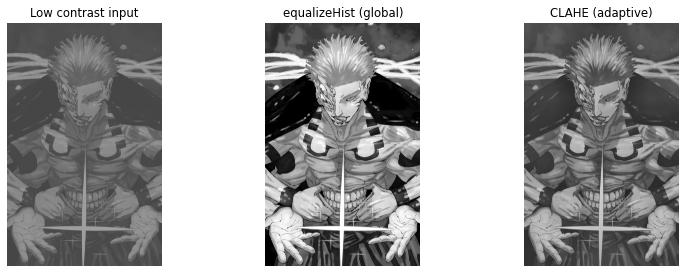

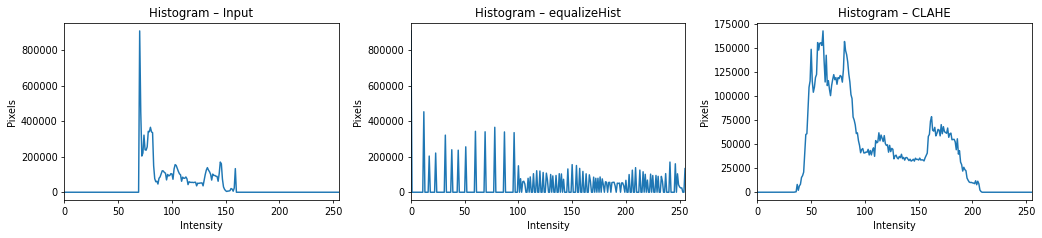

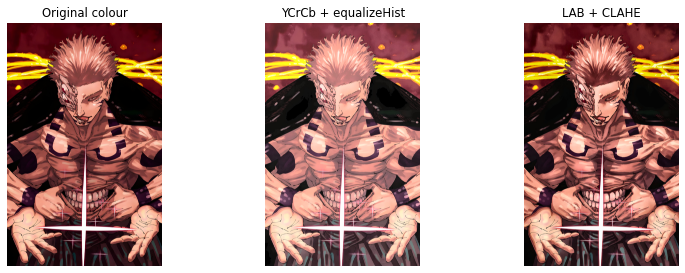

In [24]:
# ---------- Show WHY it works: a deliberately low-contrast image + histograms ----------
low_contrast = cv2.convertScaleAbs(image, alpha=0.35, beta=70)          # squash values into a narrow band
eq      = cv2.equalizeHist(low_contrast)
clahe   = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
eq_clahe = clahe.apply(low_contrast)

show([low_contrast, eq, eq_clahe],
     ['Low contrast input', 'equalizeHist (global)', 'CLAHE (adaptive)'], cols=3)

fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))
for ax, im, t in zip(axes, [low_contrast, eq, eq_clahe], ['Input', 'equalizeHist', 'CLAHE']):
    hist = cv2.calcHist([im], [0], None, [256], [0, 256])               # (256, 1)
    ax.plot(hist); ax.set_xlim(0, 255); ax.set_title(f'Histogram – {t}')
    ax.set_xlabel('Intensity'); ax.set_ylabel('Pixels')
plt.tight_layout(); plt.show()

# ---------- Colour image: equalize only the brightness channel ----------
ycrcb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2YCrCb)
ycrcb[:, :, 0] = cv2.equalizeHist(ycrcb[:, :, 0])                       # Y = luminance
color_eq = cv2.cvtColor(ycrcb, cv2.COLOR_YCrCb2RGB)

lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
lab[:, :, 0] = clahe.apply(lab[:, :, 0])                                # L = lightness, CLAHE
color_clahe = cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)

show([img_rgb, color_eq, color_clahe],
     ['Original colour', 'YCrCb + equalizeHist', 'LAB + CLAHE'], cols=3)

---
## 12. Extras that connect to the manual's terminology
Quick demos of *edge detection* and *segmentation-style masking* (terms defined in Section 1.2), plus channel split/merge.

| Function | What it does | Parameters |
|---|---|---|
| `cv2.split(img)` / `cv2.merge([c1,c2,c3])` | Separate a colour image into channels / combine them back. | list of single-channel arrays (same order!) |
| `cv2.Canny(image, threshold1, threshold2)` | Multi-stage **edge detector**. | `threshold1/2`: low / high hysteresis thresholds (ratio ≈ 1:2 or 1:3). Pixels above high = edge; between = edge only if connected to a strong edge |
| `cv2.inRange(src, lower, upper)` | Binary **mask** of pixels within a colour range — simple colour segmentation. | `lower`, `upper`: per-channel bounds |

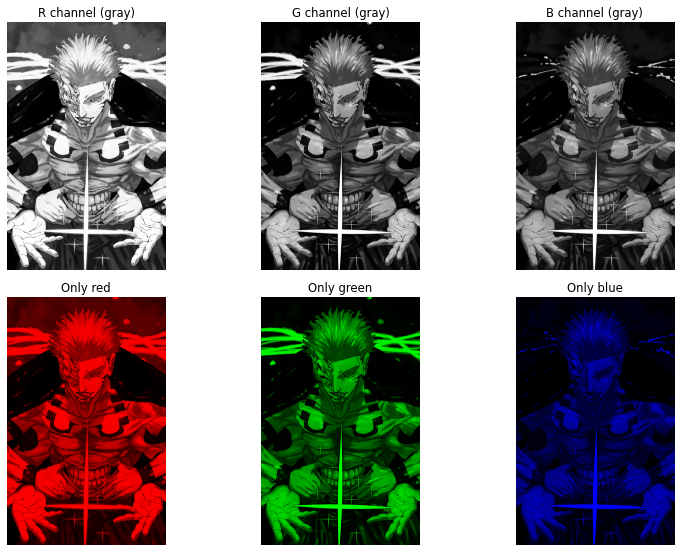

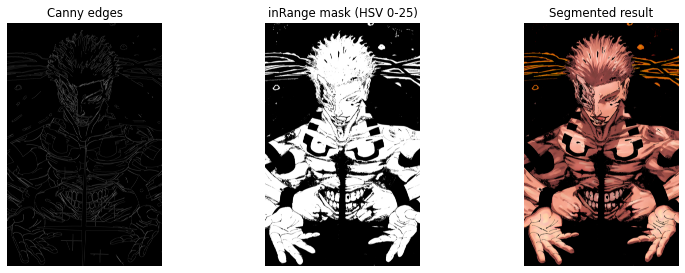

In [25]:
# ---------- split / merge ----------
b, g, r = cv2.split(img_bgr)                               # BGR order
zeros = np.zeros_like(b)
only_red   = cv2.merge([zeros, zeros, r])                  # keep red, zero others (BGR) 
only_green = cv2.merge([zeros, g, zeros])
only_blue  = cv2.merge([b, zeros, zeros])
to_rgb = lambda x: cv2.cvtColor(x, cv2.COLOR_BGR2RGB)
show([r, g, b, to_rgb(only_red), to_rgb(only_green), to_rgb(only_blue)],
     ['R channel (gray)', 'G channel (gray)', 'B channel (gray)', 'Only red', 'Only green', 'Only blue'], cols=3)

# ---------- Edge detection (blur first to reduce noise) ----------
gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
edges = cv2.Canny(cv2.GaussianBlur(gray, (5, 5), 0), threshold1=50, threshold2=150)

# ---------- Colour segmentation with inRange (HSV) ----------
hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
seg_mask = cv2.inRange(hsv, (0, 60, 60), (25, 255, 255))             # reddish/orange hues
segmented = cv2.bitwise_and(img_rgb, img_rgb, mask=seg_mask)
show([edges, seg_mask, segmented], ['Canny edges', 'inRange mask (HSV 0-25)', 'Segmented result'], cols=3)

---
## 13. 🧩 LAB TEMPLATE — copy this for your own lab tasks
A complete, reusable skeleton: **load → validate → convert → process → display → save**. Change the `process()` function and the config at the top.

Loaded: 2598 x 4077 (WxH), channels=3, dtype=uint8


,B,G,R
count,"10,592,046.00","10,592,046.00","10,592,046.00"
mean,58.52,68.33,119.96
std,59.50,73.74,87.99
min,0.00,0.00,0.00
25%,10.00,3.00,43.00
50%,40.00,46.00,97.00
75%,91.00,119.00,209.00
max,255.00,255.00,255.00


Saved: ['blended.png', 'crop_(left).png', 'gaussian_blur.png', 'grayscale.png', 'hist.png', 'original.png', 'resized.png', 'rotated.png', 'text.png', 'threshold.png']


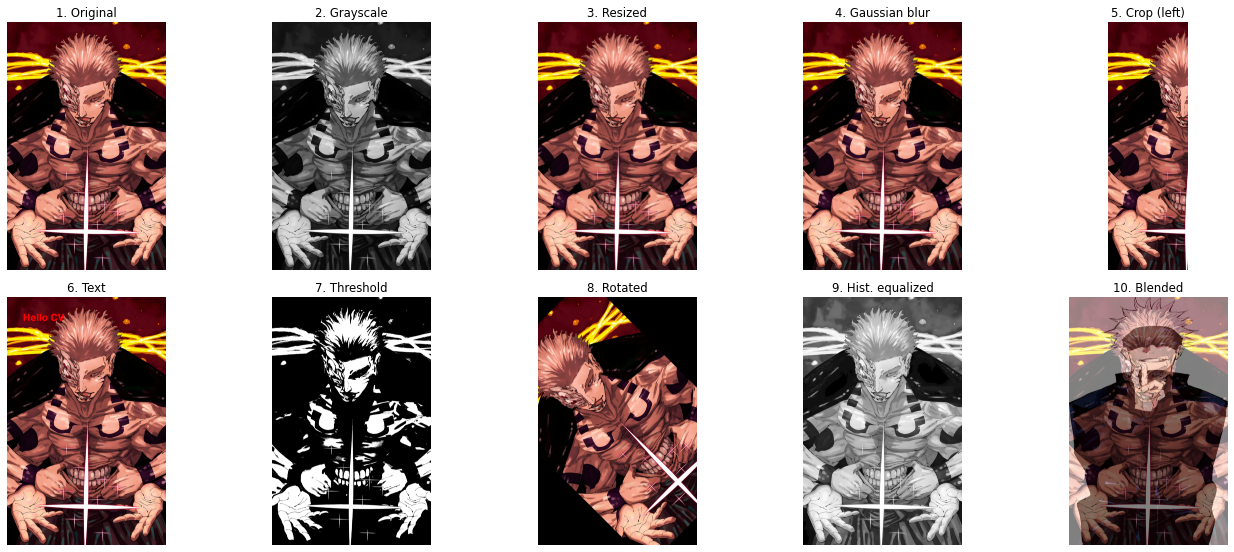

In [26]:
# =============================================================
#  LAB TEMPLATE  —  Computer Vision (AI-4002)
# =============================================================
import os, cv2, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# ---------------- 1. CONFIG ----------------
CFG = dict(
    image_path  = 'sukuna.jpg',
    image2_path = 'gojo.png',           # second real image for blending
    out_dir     = 'lab_outputs',
    scale       = 0.5,                  # resize factor
    blur_k      = 15,                   # odd!
    thresh      = 127,
    angle       = 45,
)
os.makedirs(CFG['out_dir'], exist_ok=True)

# ---------------- 2. LOAD + VALIDATE ----------------
def load_bgr(path):
    img = cv2.imread(path)
    if img is None:
        raise FileNotFoundError(f"Image not found: {path}")
    return img

bgr  = load_bgr(CFG['image_path'])
bgr2 = load_bgr(CFG['image2_path'])
rgb  = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)                 # for Matplotlib
rgb2 = cv2.cvtColor(bgr2, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)                # for thresholding / equalization
H, W = bgr.shape[:2]
print(f"Loaded: {W} x {H} (WxH), channels={bgr.shape[2]}, dtype={bgr.dtype}")

# ---------------- 3. OPERATIONS (one result per key) ----------------
def process(rgb, gray, rgb2, cfg):
    h, w = rgb.shape[:2]
    results = {}
    results['1. Original']      = rgb
    results['2. Grayscale']     = gray
    results['3. Resized']       = cv2.resize(rgb, None, fx=cfg['scale'], fy=cfg['scale'], interpolation=cv2.INTER_AREA)
    results['4. Gaussian blur'] = cv2.GaussianBlur(rgb, (cfg['blur_k'], cfg['blur_k']), 0)
    results['5. Crop (left)']   = rgb[:, :w // 2]
    txt = rgb.copy()
    cv2.putText(txt, 'Hello CV', (int(w*.1), int(h*.1)), cv2.FONT_HERSHEY_SIMPLEX, w/450, (255, 0, 0), 2, cv2.LINE_AA)
    results['6. Text']          = txt
    results['7. Threshold']     = cv2.threshold(gray, cfg['thresh'], 255, cv2.THRESH_BINARY)[1]
    M = cv2.getRotationMatrix2D((w / 2, h / 2), cfg['angle'], 1)
    results['8. Rotated']       = cv2.warpAffine(rgb, M, (w, h))
    results['9. Hist. equalized'] = cv2.equalizeHist(gray)
    rgb2_resized = cv2.resize(rgb2, (w, h), interpolation=cv2.INTER_AREA)
    results['10. Blended']      = cv2.addWeighted(rgb, 0.5, rgb2_resized, 0.5, 0)
    return results

results = process(rgb, gray, rgb2, CFG)

# ---------------- 4. DISPLAY ----------------
show(list(results.values()), list(results.keys()), cols=5)

# ---------------- 5. (optional) PIXEL STATISTICS ----------------
df = pd.DataFrame(bgr.reshape(-1, 3), columns=['B', 'G', 'R'])
display(df.describe().round(2))

# ---------------- 6. SAVE ----------------
for name, im in results.items():
    fname = os.path.join(CFG['out_dir'], name.split('. ')[1].replace(' ', '_').lower() + '.png')
    to_save = cv2.cvtColor(im, cv2.COLOR_RGB2BGR) if im.ndim == 3 else im   # imwrite wants BGR!
    cv2.imwrite(fname, to_save)
print("Saved:", sorted(os.listdir(CFG['out_dir'])))

---
## 14. Master function index (searchable)
Every function from the lab in one table. Filter in code, e.g. `index[index.Category == 'Filtering']` or `index[index.Function.str.contains('thresh', case=False)]`.

In [27]:
rows = [
 # Function, Category, Purpose, Key parameters, Returns / gotcha
 ("cv2.imread(path, flags)", "I/O", "Read image from disk", "flags: IMREAD_COLOR(1) / GRAYSCALE(0) / UNCHANGED(-1)", "BGR ndarray, or None if path wrong"),
 ("cv2.imwrite(path, img, params)", "I/O", "Save image", "params: IMWRITE_JPEG_QUALITY, PNG_COMPRESSION", "bool; expects BGR"),
 ("cv2.imshow(name, img)", "I/O", "Desktop window display", "name, img", "Not for Jupyter; needs waitKey"),
 ("cv2.waitKey(ms)", "I/O", "Wait for key press", "0 = forever", "key code"),
 ("cv2.destroyAllWindows()", "I/O", "Close OpenCV windows", "-", "-"),
 ("cv2.cvtColor(src, code)", "Colour", "Convert colour space", "COLOR_BGR2RGB / BGR2GRAY / BGR2HSV / BGR2LAB / BGR2YCrCb", "new image; GRAY → 2-D"),
 ("cv2.split(img) / cv2.merge(list)", "Colour", "Separate / combine channels", "list of channels", "tuple of 2-D arrays / image"),
 ("cv2.resize(src, dsize, fx, fy, interpolation)", "Geometry", "Change size", "dsize=(W,H) or fx,fy; INTER_AREA shrink, CUBIC enlarge", "resized image"),
 ("img[y1:y2, x1:x2]", "Geometry", "Crop (NumPy slicing)", "rows first, then columns", "VIEW — use .copy()"),
 ("cv2.getRotationMatrix2D(center, angle, scale)", "Geometry", "Build 2x3 rotation matrix", "center=(x,y); +angle = CCW", "2x3 float matrix"),
 ("cv2.warpAffine(src, M, dsize, flags, borderMode, borderValue)", "Geometry", "Apply affine transform (rotate/translate/scale)", "dsize=(W,H)", "corners cropped, black fill"),
 ("cv2.rotate(src, code)", "Geometry", "Lossless 90/180° rotation", "ROTATE_90_CLOCKWISE / 180 / 90_COUNTERCLOCKWISE", "rotated image"),
 ("cv2.flip(src, flipCode)", "Geometry", "Mirror", "1 horiz, 0 vert, -1 both", "flipped image"),
 ("cv2.GaussianBlur(src, ksize, sigmaX)", "Filtering", "Gaussian smoothing", "ksize odd (w,h); sigma 0 = auto", "blurred image"),
 ("cv2.blur(src, ksize)", "Filtering", "Box (mean) blur", "ksize (w,h)", "blurred image"),
 ("cv2.medianBlur(src, ksize)", "Filtering", "Median blur (salt & pepper)", "ksize odd int", "blurred image"),
 ("cv2.bilateralFilter(src, d, sigmaColor, sigmaSpace)", "Filtering", "Edge-preserving blur", "d, sigmaColor, sigmaSpace", "blurred image"),
 ("cv2.filter2D(src, ddepth, kernel)", "Filtering", "Custom convolution kernel", "ddepth=-1, kernel float matrix", "filtered image"),
 ("cv2.Canny(img, t1, t2)", "Edges", "Edge detection", "low / high thresholds", "binary edge map"),
 ("cv2.threshold(src, thresh, maxval, type)", "Segmentation", "Global threshold", "type: BINARY, BINARY_INV, TRUNC, TOZERO, TOZERO_INV (+OTSU/TRIANGLE)", "(ret, dst) — TWO values"),
 ("cv2.adaptiveThreshold(src, maxValue, method, type, blockSize, C)", "Segmentation", "Local threshold", "method: MEAN_C / GAUSSIAN_C; blockSize odd", "binary image"),
 ("cv2.inRange(src, lower, upper)", "Segmentation", "Colour-range mask", "lower, upper bounds", "binary mask"),
 ("cv2.add(a, b)", "Arithmetic", "Saturated add (cap 255)", "same size & type", "image"),
 ("cv2.addWeighted(a, α, b, β, γ)", "Arithmetic", "Weighted blend a·α + b·β + γ", "α+β=1 typical", "image"),
 ("cv2.subtract(a, b) / cv2.absdiff(a, b)", "Arithmetic", "Saturated subtract / absolute difference", "same size & type", "image"),
 ("cv2.bitwise_and(a, b, mask)", "Arithmetic", "Masking / ROI extraction", "mask: 8-bit 1-ch", "image"),
 ("cv2.equalizeHist(src)", "Histogram", "Global contrast equalization", "8-bit single channel only", "gray image"),
 ("cv2.createCLAHE(clipLimit, tileGridSize).apply(img)", "Histogram", "Adaptive equalization", "clipLimit≈2-4; tiles (8,8)", "gray image"),
 ("cv2.calcHist([img], [ch], mask, [bins], [0,256])", "Histogram", "Compute histogram", "list args", "(256,1) array"),
 ("cv2.putText(img, text, org, font, scale, color, thickness, lineType)", "Drawing", "Write text (in place)", "org = bottom-left (x,y); colour order = image order", "modifies img"),
 ("cv2.getTextSize(text, font, scale, thickness)", "Drawing", "Measure text", "-", "((w,h), baseline)"),
 ("cv2.rectangle / circle / line / arrowedLine / ellipse / polylines", "Drawing", "Draw shapes (in place)", "points are (x,y); thickness -1 = fill", "modifies img"),
 ("img.shape / .dtype / .size / .reshape(-1,3)", "NumPy", "Inspect / flatten array", "shape=(H,W,C)", "-"),
 ("plt.imshow(X, cmap)", "Matplotlib", "Show image", "cmap='gray' for 2-D; RGB for colour", "-"),
 ("plt.figure(figsize) / title / axis('off') / show()", "Matplotlib", "Figure, title, hide axes, render", "-", "-"),
 ("pd.DataFrame(arr, columns=['B','G','R']) / df.describe()", "Pandas", "Pixel table & statistics", "BGR order!", "DataFrame"),
]
index = pd.DataFrame(rows, columns=["Function", "Category", "Purpose", "Key parameters", "Returns / gotcha"])
print(f"{len(index)} entries | categories: {sorted(index.Category.unique())}")
with pd.option_context('display.max_rows', None, 'display.max_colwidth', None):
    display(index)

# Example filter:
# index[index.Category == 'Filtering']

36 entries | categories: ['Arithmetic', 'Colour', 'Drawing', 'Edges', 'Filtering', 'Geometry', 'Histogram', 'I/O', 'Matplotlib', 'NumPy', 'Pandas', 'Segmentation']


,Function,Category,Purpose,Key parameters,Returns / gotcha
0,"cv2.imread(path, flags)",I/O,Read image from disk,flags: IMREAD_COLOR(1) / GRAYSCALE(0) / UNCHANGED(-1),"BGR ndarray, or None if path wrong"
1,"cv2.imwrite(path, img, params)",I/O,Save image,"params: IMWRITE_JPEG_QUALITY, PNG_COMPRESSION",bool; expects BGR
2,"cv2.imshow(name, img)",I/O,Desktop window display,"name, img",Not for Jupyter; needs waitKey
3,cv2.waitKey(ms),I/O,Wait for key press,0 = forever,key code
4,cv2.destroyAllWindows(),I/O,Close OpenCV windows,-,-
5,"cv2.cvtColor(src, code)",Colour,Convert colour space,COLOR_BGR2RGB / BGR2GRAY / BGR2HSV / BGR2LAB / BGR2YCrCb,new image; GRAY → 2-D
6,cv2.split(img) / cv2.merge(list),Colour,Separate / combine channels,list of channels,tuple of 2-D arrays / image
7,"cv2.resize(src, dsize, fx, fy, interpolation)",Geometry,Change size,"dsize=(W,H) or fx,fy; INTER_AREA shrink, CUBIC enlarge",resized image
8,"img[y1:y2, x1:x2]",Geometry,Crop (NumPy slicing),"rows first, then columns",VIEW — use .copy()
9,"cv2.getRotationMatrix2D(center, angle, scale)",Geometry,Build 2x3 rotation matrix,"center=(x,y); +angle = CCW",2x3 float matrix


---
# 15. Lab 01 Tasks (from *Lab 01 Tasks.pdf*)
**Introductory Computer Vision Lab (Extended: 2 Hours)** — task statements reproduced from the PDF, each followed by a working solution that reuses the setup cell (`img_bgr`, `img_rgb`, `image2`, `IMAGE_PATH`, `show`, ...).

> *All image visualization tasks must utilize Matplotlib subplots for side-by-side comparisons unless stated otherwise.*

## Part 1: Environment Setup & Validation
Before beginning the tasks, ensure your notebook environment is correctly configured to handle image processing and plotting.

- **1.1 Installation:** Use Jupyter magic commands to install the required libraries by running `%pip install opencv-python` and `%pip install matplotlib` in your first cell.
- **1.2 Import & Validate:** Import `cv2` and `matplotlib.pyplot as plt`. Write a quick validation script to ensure they are working properly before proceeding.

In [ ]:
# 1.1 Installation (uncomment on a fresh environment)
# %pip install opencv-python
# %pip install matplotlib

# 1.2 Import & validate
import cv2
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

print("OpenCV version    :", cv2.__version__)
print("Matplotlib version:", matplotlib.__version__)
test = np.zeros((50, 50, 3), np.uint8); cv2.circle(test, (25, 25), 15, (255, 0, 0), -1)   # cv2 works?
plt.imshow(test); plt.title("validation"); plt.axis('off'); plt.show()                       # plt works?
print("Validation OK")

### Task 4: Interactive Geometry & Blank Canvas
- Create a **800x800** blank black image using NumPy.
- Use OpenCV to draw a geometric pattern (e.g., a target board with **5** concentric circles of alternating colors).
- Add a bounding box (rectangle) around the outermost circle and calculate/print the exact center coordinates of the canvas.

In [ ]:
canvas = np.zeros((800, 800, 3), dtype=np.uint8)          # black, RGB order since we display with matplotlib
cx, cy = canvas.shape[1] // 2, canvas.shape[0] // 2       # (x, y) centre
colors = [(255, 0, 0), (255, 255, 255)]                   # alternate red / white
radii = [350, 280, 210, 140, 70]                          # outermost first so inner circles paint on top
for i, r in enumerate(radii):
    cv2.circle(canvas, (cx, cy), r, colors[i % 2], -1)
R = radii[0]
cv2.rectangle(canvas, (cx - R, cy - R), (cx + R, cy + R), (0, 255, 0), 3)   # bounding box of outer circle
print(f"Canvas centre: (x={cx}, y={cy})   |  box: ({cx-R},{cy-R}) -> ({cx+R},{cy+R})")
plt.figure(figsize=(6, 6)); plt.imshow(canvas); plt.axis('off'); plt.title('Target board'); plt.show()

#### 🧩 Task 4 template — reusable for ANY shape / pattern
Describe the drawing as **data** (a list of shape dicts), then one `draw_shapes()` call renders it. To change the task, edit only the CONFIG block and the `SHAPES` list.

| `type` | Required keys | Optional keys |
|---|---|---|
| `circle` | `center=(x, y)`, `radius` | `color`, `thickness` (`-1` = filled) |
| `rect` | `pt1=(x, y)`, `pt2=(x, y)` | `color`, `thickness` |
| `ellipse` | `center`, `axes=(a, b)` | `angle`, `start`, `end`, `color`, `thickness` |
| `line` / `arrow` | `pt1`, `pt2` | `color`, `thickness` |
| `polygon` | `points=[(x, y), ...]` | `color`, `thickness` (`-1` = filled), `closed` |
| `text` | `text`, `org=(x, y)` | `scale`, `color`, `thickness` |

Helpers: `concentric(...)` builds N rings, `regular_polygon(...)` builds an n-gon (triangle, hexagon, star-ish...), `bbox_of(shape)` gives a shape's bounding box.
> Coordinates are `(x, y)` = (column, row). Colours are **RGB** here because the canvas is displayed with Matplotlib (use BGR if you show/save with OpenCV).

In [ ]:
# ================= CONFIG =================
H, W       = 800, 800                       # canvas size (rows, cols)
BG_COLOR   = (0, 0, 0)                      # background (RGB)
SAVE_AS    = None                           # e.g. os.path.join(OUTPUT_DIR, 'task4.png') or None
CENTER     = (W // 2, H // 2)               # (x, y)

# ================= HELPERS =================
def concentric(center, radii, colors, thickness=-1):
    """N circles, outermost first (so inner ones paint on top); colours cycle (alternating)."""
    return [dict(type='circle', center=center, radius=r, color=colors[i % len(colors)], thickness=thickness)
            for i, r in enumerate(sorted(radii, reverse=True))]

def regular_polygon(center, radius, n_sides, rotation_deg=-90):
    """Vertices of a regular n-gon (n=3 triangle, 6 hexagon...). -90 puts the first vertex at the top."""
    cx, cy = center
    ang = np.deg2rad(rotation_deg + np.arange(n_sides) * 360 / n_sides)
    return [(int(cx + radius * np.cos(a)), int(cy + radius * np.sin(a))) for a in ang]

def bbox_of(s):
    """Axis-aligned bounding box (x1, y1, x2, y2) of a circle / ellipse / polygon / rect shape dict."""
    t = s['type']
    if t == 'circle':
        (cx, cy), r = s['center'], s['radius']; return cx - r, cy - r, cx + r, cy + r
    if t == 'ellipse':
        (cx, cy), (a, b) = s['center'], s['axes']; return cx - a, cy - b, cx + a, cy + b
    if t == 'polygon':
        xs, ys = zip(*s['points']); return min(xs), min(ys), max(xs), max(ys)
    if t == 'rect':
        (x1, y1), (x2, y2) = s['pt1'], s['pt2']; return min(x1, x2), min(y1, y2), max(x1, x2), max(y1, y2)
    raise ValueError(f"bbox_of: unsupported type {t!r}")

def draw_shapes(canvas, shapes):
    for s in shapes:
        t, col, th = s['type'], s.get('color', (255, 255, 255)), s.get('thickness', 2)
        if   t == 'circle':  cv2.circle(canvas, s['center'], s['radius'], col, th)
        elif t == 'rect':    cv2.rectangle(canvas, s['pt1'], s['pt2'], col, th)
        elif t == 'ellipse': cv2.ellipse(canvas, s['center'], s['axes'], s.get('angle', 0),
                                         s.get('start', 0), s.get('end', 360), col, th)
        elif t == 'line':    cv2.line(canvas, s['pt1'], s['pt2'], col, th)
        elif t == 'arrow':   cv2.arrowedLine(canvas, s['pt1'], s['pt2'], col, th)
        elif t == 'polygon':
            pts = np.array(s['points'], np.int32).reshape(-1, 1, 2)
            if th == -1: cv2.fillPoly(canvas, [pts], col)
            else:        cv2.polylines(canvas, [pts], s.get('closed', True), col, th)
        elif t == 'text':    cv2.putText(canvas, s['text'], s['org'], cv2.FONT_HERSHEY_SIMPLEX,
                                         s.get('scale', 1), col, th, cv2.LINE_AA)
        else: raise ValueError(f"unknown shape type {t!r}")
    return canvas

# ================= SHAPES (edit this) =================
RED, WHITE, GREEN = (255, 0, 0), (255, 255, 255), (0, 255, 0)
SHAPES  = concentric(CENTER, radii=[70, 140, 210, 280, 350], colors=[RED, WHITE])   # 5-ring target board
outer   = SHAPES[0]                                                                 # outermost shape
x1, y1, x2, y2 = bbox_of(outer)
SHAPES += [dict(type='rect', pt1=(x1, y1), pt2=(x2, y2), color=GREEN, thickness=3)]  # bounding box
# other examples (uncomment):
# SHAPES  = [dict(type='polygon', points=regular_polygon(CENTER, 300, 6), color=WHITE, thickness=-1)]   # filled hexagon
# SHAPES += [dict(type='ellipse', center=CENTER, axes=(300, 150), angle=30, color=RED, thickness=4)]
# SHAPES += [dict(type='line', pt1=(0, 0), pt2=(W, H), color=GREEN, thickness=2)]
# SHAPES += [dict(type='text', text='Hello', org=(50, 60), scale=2, color=WHITE, thickness=3)]

# ================= RENDER =================
canvas = np.full((H, W, 3), BG_COLOR, dtype=np.uint8)
draw_shapes(canvas, SHAPES)
print(f"Canvas {W}x{H}  |  centre (x, y) = ({W // 2}, {H // 2})  |  outer bbox = ({x1},{y1}) -> ({x2},{y2})")
if SAVE_AS: cv2.imwrite(SAVE_AS, cv2.cvtColor(canvas, cv2.COLOR_RGB2BGR))          # imwrite expects BGR
plt.figure(figsize=(6, 6)); plt.imshow(canvas); plt.axis('off'); plt.title('Canvas'); plt.show()

### Task 5: Advanced Blurring & NumPy ROI Extraction
- Load a high-resolution image (safely check if it loaded, convert to RGB).
- Apply a heavy Gaussian Blur (e.g., **25x25** kernel).
- Using NumPy array slicing, extract a **300x300** pixel Region of Interest (ROI) from the *exact center* of both the original and blurred images.
- Plot the two ROIs side-by-side using Matplotlib subplots, ensuring axes are turned off with `plt.axis('off')` and custom titles are added to each subplot using `fontsize` and color parameters.

In [ ]:
image = cv2.imread(IMAGE_PATH)
if image is None:
    print("Error: Image not found.")
else:
    rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    blurred = cv2.GaussianBlur(rgb, (25, 25), 0)
    h, w = rgb.shape[:2]
    S = min(300, h, w)                                    # guard for images smaller than 300 px
    y0, x0 = (h - S) // 2, (w - S) // 2                   # top-left corner of the centred ROI
    roi_orig, roi_blur = rgb[y0:y0 + S, x0:x0 + S], blurred[y0:y0 + S, x0:x0 + S]

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1); plt.imshow(roi_orig); plt.axis('off')
    plt.title('Original ROI', fontsize=14, color='darkgreen')
    plt.subplot(1, 2, 2); plt.imshow(roi_blur); plt.axis('off')
    plt.title('Gaussian Blur 25x25 ROI', fontsize=14, color='darkred')
    plt.tight_layout(); plt.show()

### Task 6: Alpha Blending & Typography
- Create a stylized image caption. Load an image and create a solid color overlay (e.g., a blue rectangle) that covers the bottom **20%** of the image.
- Blend the original image and the rectangle overlay using `cv2.addWeighted()` so the overlay is semi-transparent.
- Use `cv2.putText()` to write a title over the transparent box.

In [ ]:
image = cv2.imread(IMAGE_PATH)
if image is None:
    print("Error: Image not found.")
else:
    h, w = image.shape[:2]
    overlay = image.copy()
    cv2.rectangle(overlay, (0, int(h * 0.8)), (w, h), (255, 0, 0), -1)      # BGR blue, bottom 20 %
    alpha = 0.5
    captioned = cv2.addWeighted(overlay, alpha, image, 1 - alpha, 0)        # semi-transparent box
    scale = w / 800                                                         # scale text to image size
    cv2.putText(captioned, "King of Curses", (int(w * 0.05), int(h * 0.92)),
                cv2.FONT_HERSHEY_SIMPLEX, max(0.6, 1.5 * scale), (255, 255, 255),
                max(1, int(3 * scale)), cv2.LINE_AA)
    show([cv2.cvtColor(image, cv2.COLOR_BGR2RGB), cv2.cvtColor(captioned, cv2.COLOR_BGR2RGB)],
         ['Original', 'Caption (alpha blend)'], cols=2)

### Task 7: Matrix-Based Rotation & Adaptive Thresholding
- Load a grayscale document or high-contrast image.
- Instead of basic binary thresholding, apply both **Global Binary Thresholding** and **Adaptive Thresholding** (`cv2.adaptiveThreshold`). Compare them side-by-side.
- Use `cv2.getRotationMatrix2D()` to create a rotation matrix, and rotate the adaptive threshold output by exactly **45** degrees, scaling it by **0.8** so the corners don't get cut off.

In [ ]:
gray = cv2.imread(IMAGE_PATH, cv2.IMREAD_GRAYSCALE)
if gray is None:
    print("Error: Image not found.")
else:
    _, global_bin = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)
    adaptive = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                     cv2.THRESH_BINARY, 11, 2)           # blockSize (odd), C
    h, w = adaptive.shape
    M = cv2.getRotationMatrix2D((w / 2, h / 2), 45, 0.8)                  # centre, angle, scale
    rotated = cv2.warpAffine(adaptive, M, (w, h))
    show([gray, global_bin, adaptive, rotated],
         ['Gray', 'Global binary (T=127)', 'Adaptive Gaussian', 'Adaptive rotated 45° x0.8'], cols=4)

### Task 8: Masking with Bitwise Logic
- Load two different images and resize them to be exactly the same dimensions (e.g., **500x500**).
- Create a binary mask (a black image with a thick white polygon or circle in the center).
- Use `cv2.bitwise_and` to cut out the polygon shape from the first image.
- Use `cv2.bitwise_not` to invert the mask, and use it to cut out the *background* from the second image. Combine them using `cv2.bitwise_or`.

In [ ]:
a = cv2.resize(img_bgr, (500, 500))
b = cv2.resize(image2,  (500, 500))
mask = np.zeros((500, 500), dtype=np.uint8)
cv2.circle(mask, (250, 250), 180, 255, -1)                # white filled circle (use cv2.fillPoly for a polygon)
inv_mask = cv2.bitwise_not(mask)

fg = cv2.bitwise_and(a, a, mask=mask)                     # shape cut out of image 1
bg = cv2.bitwise_and(b, b, mask=inv_mask)                 # background of image 2
combined = cv2.bitwise_or(fg, bg)

bgr2rgb = lambda x: cv2.cvtColor(x, cv2.COLOR_BGR2RGB)
show([bgr2rgb(a), bgr2rgb(b), mask, bgr2rgb(fg), bgr2rgb(bg), bgr2rgb(combined)],
     ['Image 1', 'Image 2', 'Mask', 'AND (img1 x mask)', 'AND (img2 x NOT mask)', 'OR = combined'], cols=3)

### Task 9: Statistical Image Profiling with Pandas
- Load an image and flatten its 2D pixel arrays for the **Red**, **Green**, and **Blue** channels into **1D** arrays.
- Load these three arrays into a Pandas DataFrame with columns `['Red', 'Green', 'Blue']`.
- Use Pandas built-in functions (`.describe()`) to analyze the mean, min, max, and standard deviation of each color channel. Print the DataFrame summary to the console.

In [ ]:
image = cv2.imread(IMAGE_PATH)
if image is None:
    print("Error: Image not found.")
else:
    rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    df = pd.DataFrame({'Red': rgb[:, :, 0].flatten(),         # 2-D channel -> 1-D array
                       'Green': rgb[:, :, 1].flatten(),
                       'Blue': rgb[:, :, 2].flatten()})
    print(df.describe())                                      # count, mean, std, min, quartiles, max